# Customer Churn Prediction

Predicting whether a telecom customer will cancel their subscription, using behavioural and account data. A classic business-critical ML problem: identifying at-risk customers before they leave.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Exploratory Data Analysis

Checking class balance, missing values, and key feature distributions before preprocessing.

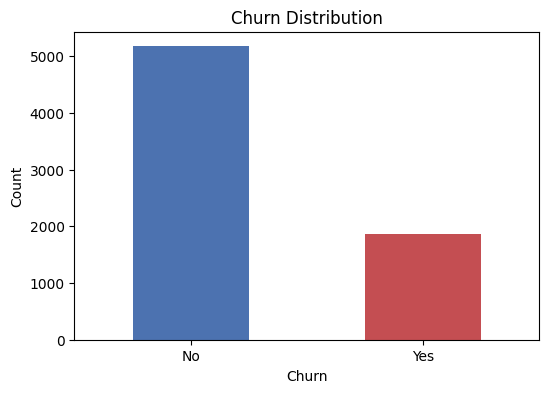

Churn rate: 26.5%


In [3]:
plt.figure(figsize=(6,4))
df['Churn'].value_counts().plot(kind='bar', color=['#4C72B0','#C44E52'])
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

churn_rate = df['Churn'].value_counts(normalize=True)
print(f"Churn rate: {churn_rate['Yes']*100:.1f}%")

In [4]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# TotalCharges is loaded as string due to blank entries, fix it
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"\nMissing after conversion: {df['TotalCharges'].isnull().sum()}")
df = df.dropna(subset=['TotalCharges'])
print(f"Shape after dropping: {df.shape}")

Missing values per column:
Series([], dtype: int64)

Missing after conversion: 11
Shape after dropping: (7032, 21)


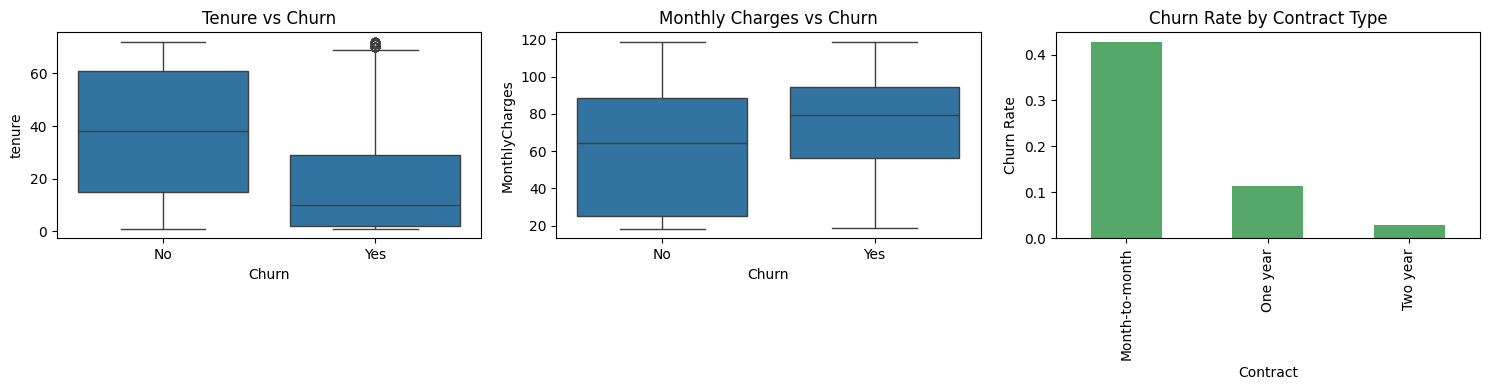

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[0])
axes[0].set_title("Tenure vs Churn")

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1])
axes[1].set_title("Monthly Charges vs Churn")

df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean()).plot(kind='bar', ax=axes[2], color='#55A868')
axes[2].set_title("Churn Rate by Contract Type")
axes[2].set_ylabel("Churn Rate")

plt.tight_layout()
plt.show()

## Preprocessing

Encoding categorical variables, scaling numerical features, and splitting the dataset.

In [6]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df_model = df.drop('customerID', axis=1)

# Encode target
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

# Encode categorical features
cat_cols = df_model.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean()*100:.1f}% | Test churn rate: {y_test.mean()*100:.1f}%")

Train: (5625, 19) | Test: (1407, 19)
Train churn rate: 26.6% | Test churn rate: 26.6%


## Model Training

Comparing Logistic Regression and Random Forest, two standard approaches for churn prediction. Class weighting is used to handle the imbalance between churned and retained customers.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

log_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)
log_proba = log_model.predict_proba(X_test_scaled)[:, 1]

log_acc = accuracy_score(y_test, log_pred)
log_auc = roc_auc_score(y_test, log_proba)

print(f"Logistic Regression Accuracy: {log_acc:.4f}")
print(f"Logistic Regression ROC-AUC: {log_auc:.4f}\n")
print(classification_report(y_test, log_pred, target_names=['Stayed', 'Churned']))

Logistic Regression Accuracy: 0.7264
Logistic Regression ROC-AUC: 0.8337

              precision    recall  f1-score   support

      Stayed       0.90      0.70      0.79      1033
     Churned       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight='balanced', random_state=42
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_proba)

print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(f"Random Forest ROC-AUC: {rf_auc:.4f}\n")
print(classification_report(y_test, rf_pred, target_names=['Stayed', 'Churned']))

Random Forest Accuracy: 0.7740
Random Forest ROC-AUC: 0.8327

              precision    recall  f1-score   support

      Stayed       0.88      0.80      0.84      1033
     Churned       0.56      0.71      0.62       374

    accuracy                           0.77      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.80      0.77      0.78      1407



## Model Comparison

              Model  Accuracy  ROC-AUC
Logistic Regression  0.726368 0.833703
      Random Forest  0.773987 0.832657


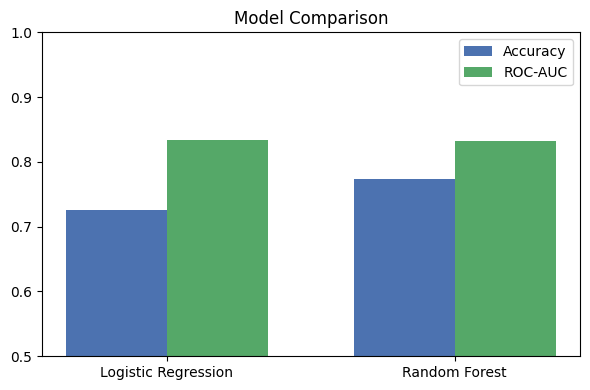

In [9]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [log_acc, rf_acc],
    "ROC-AUC": [log_auc, rf_auc]
})
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(6,4))
x = np.arange(len(comparison))
width = 0.35
ax.bar(x - width/2, comparison["Accuracy"], width, label="Accuracy", color="#4C72B0")
ax.bar(x + width/2, comparison["ROC-AUC"], width, label="ROC-AUC", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(comparison["Model"])
ax.set_ylim(0.5, 1.0)
ax.set_title("Model Comparison")
ax.legend()
plt.tight_layout()
plt.show()

## ROC Curve

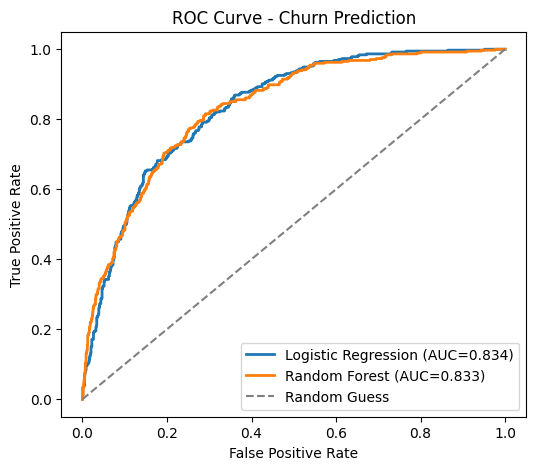

In [10]:
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_test, log_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC={log_auc:.3f})", linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={rf_auc:.3f})", linewidth=2)
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Guess')
plt.title("ROC Curve - Churn Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## Feature Importance

Identifying which factors drive churn the most, using the Random Forest model.

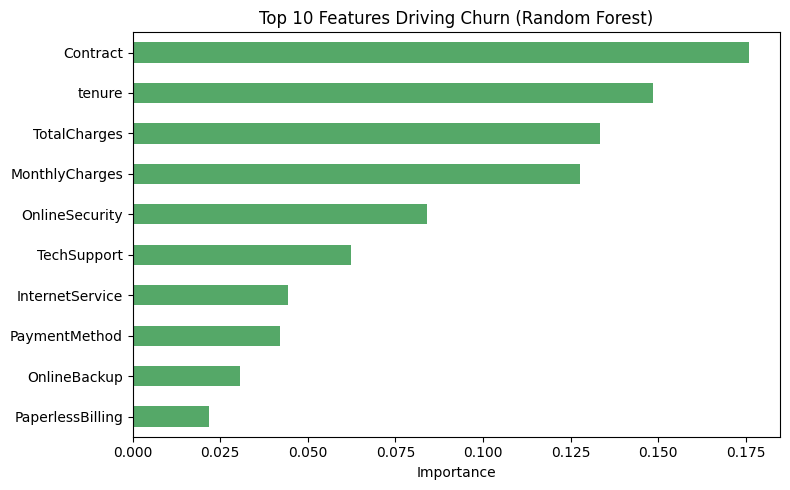

Contract            0.175994
tenure              0.148519
TotalCharges        0.133438
MonthlyCharges      0.127822
OnlineSecurity      0.083937
TechSupport         0.062413
InternetService     0.044275
PaymentMethod       0.042106
OnlineBackup        0.030547
PaperlessBilling    0.021842
dtype: float64


In [11]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top_features.plot(kind='barh', color='#55A868')
plt.title("Top 10 Features Driving Churn (Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(top_features)

## Confusion Matrix

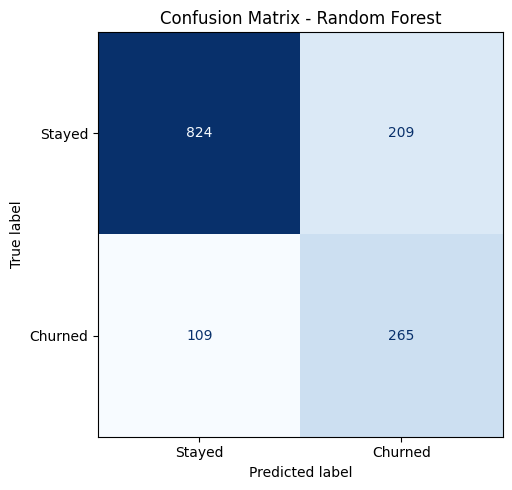

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    display_labels=['Stayed', 'Churned'],
    cmap='Blues', colorbar=False, ax=ax
)
ax.set_title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

## Business Translation

Converting model predictions into a concrete business estimate.

In [13]:
n_test = len(y_test)
n_actual_churn = y_test.sum()
n_correctly_caught = ((rf_pred == 1) & (y_test == 1)).sum()
avg_monthly_revenue = df['MonthlyCharges'].mean()

print(f"Customers in test set: {n_test}")
print(f"Customers who actually churned: {n_actual_churn}")
print(f"Churners correctly identified by the model: {n_correctly_caught} ({n_correctly_caught/n_actual_churn*100:.1f}%)")
print(f"Average monthly revenue per customer: ${avg_monthly_revenue:.2f}")

annual_value_at_risk = n_correctly_caught * avg_monthly_revenue * 12
print(f"\nAnnual revenue at risk correctly flagged by the model: ${annual_value_at_risk:,.0f}")

Customers in test set: 1407
Customers who actually churned: 374
Churners correctly identified by the model: 265 (70.9%)
Average monthly revenue per customer: $64.80

Annual revenue at risk correctly flagged by the model: $206,058


## Precision-Recall Tradeoff

Visualising how the classification threshold affects the balance between catching churners and false alarms.

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, rf_proba)

plt.figure(figsize=(7,5))
plt.plot(thresholds, precision[:-1], label="Precision", linewidth=2)
plt.plot(thresholds, recall[:-1], label="Recall", linewidth=2)
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
plt.title("Precision-Recall Tradeoff by Threshold")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()